# **10장 탐색적 요인분석**

## <span style="color: blue;">**1. 데이터 입력**</span>

![Survey](https://raw.githubusercontent.com/pilsunchoi/images4/main/10-1.png)

출처: [Kaggle: Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)

## **Gemini 설명**

이 데이터셋은 항공사 승객 만족도 조사 데이터이다. 각 승객의 인적 사항, 비행 정보, 그리고 다양한 서비스에 대한 만족도 평가가 포함되어 있으며, 최종적으로 승객이 만족했는지 여부를 예측하는 분류 문제에 사용될 수 있다.

---

데이터의 주요 특징은 다음과 같다.

### 1. 데이터 구조

* **총 데이터 수:** 103,904개
* **변수(컬럼) 수:** 25개
* **타겟 변수:** `satisfaction` ('neutral or dissatisfied' 또는 'satisfied'의 이진 분류)

---

### 2. 변수 설명

#### 승객 인적 사항 (Demographics)
* `Gender`: 성별 (Male, Female)
* `Customer Type`: 고객 유형 (Loyal Customer, disloyal Customer)
* `Age`: 승객 나이 (7세~85세 분포)

---

#### 비행 정보 (Flight Information)
* `Type of Travel`: 비행 목적 (Business travel, Personal Travel)
* `Class`: 좌석 등급 (Business, Eco, Eco Plus)
* `Flight Distance`: 비행 거리

---

#### 서비스 만족도 평가 (Services)
* 14개의 서비스 항목에 대해 0~5점 척도로 평가된 점수이다.
* `Inflight wifi service` (와이파이), `Food and drink` (식음료), `Seat comfort` (좌석 편안함), `Inflight entertainment` (기내 엔터테인먼트), `On-board service` (탑승 서비스), `Leg room service` (다리 공간), `Cleanliness` (청결도) 등이 포함된다.

---

#### 지연 정보 (Delays)
* `Departure Delay in Minutes`: 출발 지연 시간(분)
* `Arrival Delay in Minutes`: 도착 지연 시간(분)

---

### 3. 데이터 특이사항

* `Arrival Delay in Minutes` 변수에 310개의 결측치(NaN)가 존재한다. 분석 시 이를 제거하거나 평균/중앙값 등으로 대체하는 전처리가 필요할 수 있다.
* `id`와 `Unnamed: 0`은 단순 식별자이므로 모델링 시 제외하는 것이 일반적이다.
* 서비스 만족도 점수 중 0점은 '평가 없음'을 의미할 가능성이 있으므로 확인이 필요하다.

## <span style="color: blue;">**2. 탐색적 요인분석**</span>

## **Gemini 분석**

### 1. 탐색적 요인분석이란?

탐색적 요인분석(EFA: Exploratory Factor Analysis)은 다수의 변수들(여기서는 14개의 서비스 만족도 항목) 간의 상관관계를 분석하여, 이들을 소수의 잠재적 요인(Latent Factor)으로 묶어주는 통계 기법이다. 변수 축소(Dimension Reduction)와 데이터의 내재적 구조를 파악하는 데 주로 사용된다.

* **목적:** 복잡한 데이터를 단순화하고, 관측되지 않은 근본적인 원인(요인)을 찾아내어 해석을 용이하게 한다.
* **원리:** 서로 상관관계가 높은 변수들은 같은 요인에 속할 가능성이 높다는 점을 이용한다.
* **주요 개념:**
  * **요인 적재량(Factor Loading):** 각 변수와 요인 간의 상관관계 정도를 나타내며, 절댓값이 클수록 해당 요인과의 관련성이 높음을 의미한다.
  * **회전(Rotation):** 요인의 축을 회전시켜 변수들이 특정 요인에 더 명확히 묶이도록 하여 해석력을 높인다 (주로 직각 회전인 Varimax 방식이 많이 쓰인다).

---

### 2. 분석 결과 요약

데이터에 대해 EFA를 수행한 결과, 고유값(Eigenvalue)이 1 이상인 기준(Kaiser's criterion)에 따라 **총 4개의 요인**이 추출되었다. 각 요인은 다음과 같은 서비스 항목들과 강한 연관성을 보인다 (적재량 절댓값 0.4 이상 기준).

![Eigenvalue](https://raw.githubusercontent.com/pilsunchoi/images4/main/10-2.png)

#### 요인 1: 기내 편의 및 엔터테인먼트 (In-flight Comfort & Entertainment)

이 요인은 승객이 기내에 머무는 동안 직접적으로 체험하는 물리적 환경과 즐거움에 관련되어 있다.

* `Cleanliness` (-0.84)
* `Inflight entertainment` (-0.80)
* `Food and drink` (-0.78)
* `Seat comfort` (-0.74)

#### 요인 2: 예약 및 접근성 (Booking & Accessibility)

항공권 예매부터 탑승 게이트 이동까지의 과정과 관련된 편의성을 대변한다.

* `Ease of Online booking` (-0.89)
* `Inflight wifi service` (-0.74)
* `Gate location` (-0.56)
* `Departure/Arrival time convenient` (-0.52)

#### 요인 3: 인적 서비스 (Staff Service)

승무원과의 상호작용 및 서비스 태도와 관련된 항목들이 묶였다.

* `Inflight service` (-0.80)
* `Baggage handling` (-0.76)
* `On-board service` (-0.69)
* `Leg room service` (-0.47)

#### 요인 4: 온라인 탑승 수속 (Online Boarding Focus)

특이하게도 `Online boarding` 항목이 단독으로 매우 높은 적재량(-0.86)을 보이며 별도의 요인으로 분류되었다. 이는 온라인 체크인 경험이 다른 서비스들과 구별되는 독자적인 만족도 결정 요인임을 시사한다.

---

### 3. 결론 및 시사점

이 분석을 통해 14개의 복잡한 서비스 항목을 **'기내 편의', '예약 접근성', '인적 서비스', '온라인 탑승'** 이라는 4가지 핵심 차원으로 요약할 수 있다.

항공사는 이 4가지 차원을 기준으로 서비스 품질을 모니터링하고, 각 차원별 점수를 지표화(Index)하여 관리함으로써 보다 효율적인 고객 만족도 제고 전략을 수립할 수 있다. 예를 들어, '인적 서비스' 요인의 점수가 낮다면 승무원 교육을 강화하고, '예약 접근성' 요인이 문제라면 앱/웹 시스템을 개선하는 식이다.

## **ChatGPT 분석**

아래는 업로드된 `train.csv`의 서비스 평점 14개 문항(0~5점 척도)에 대해 탐색적 요인분석(EFA)을 “상관행렬 기반(주성분 요인추출) + Varimax 회전”으로 수행한 결과다. (표본이 10만+라서, 최대우도 FA를 직접 적합하기보다 상관행렬 기반 EFA로 빠르고 안정적으로 요인구조를 보는 방식)

### 1) 요인 수 선택

서비스 평점 14개 변수의 상관행렬 고유값(내림차순)은 대략

* 1: 3.80
* 2: 2.36
* 3: 2.17
* 4: 1.06
* 5: 0.95 …

Kaiser 기준(고유값 > 1)으로는 4개 요인, 그리고 병렬분석(Parallel analysis)에서도 4번째 고유값이 랜덤 기준(95% 분위)보다 커서 4개 요인이 합리적이다.

### 2) 회전 후 적재량(Varimax)

* 적재량의 부호는 임의라서(해석상 편하게) 요인별로 양(+) 방향으로 맞춰 해석했다.
* 아래는 회전 후 적재량(loading)이며, 해석 편의를 위해 값은 소수점 셋째자리 반올림.

| 변수                                |     F1 |     F2 |     F3 |     F4 |
| --------------------------------- | -----: | -----: | -----: | -----: |
| Cleanliness                       |  0.886 |  0.037 | -0.015 |  0.101 |
| Food and drink                    |  0.853 | -0.049 |  0.048 |  0.018 |
| Seat comfort                      |  0.823 |  0.018 | -0.071 |  0.206 |
| Inflight entertainment            |  0.802 |  0.422 |  0.037 |  0.052 |
| Inflight service                  |  0.074 |  0.841 |  0.049 | -0.014 |
| Baggage handling                  |  0.070 |  0.824 |  0.046 |  0.003 |
| On-board service                  |  0.118 |  0.774 | -0.020 |  0.084 |
| Leg room service                  |  0.047 |  0.595 | -0.043 |  0.195 |
| Gate location                     |  0.013 | -0.024 |  0.836 |  0.032 |
| Departure/Arrival time convenient | -0.010 |  0.085 |  0.751 |  0.130 |
| Ease of Online booking            | -0.052 |  0.002 |  0.594 |  0.675 |
| Inflight wifi service             |  0.079 |  0.091 |  0.467 |  0.714 |
| Online boarding                   |  0.298 |  0.032 | -0.114 |  0.832 |
| Checkin service                   |  0.103 |  0.346 | -0.194 |  0.299 |

### 3) 요인 해석(라벨링)

보통 적재량 0.4 이상을 “강한 적재”로 보면 다음처럼 깔끔하게 묶인다.

* F1: 기내 쾌적/편의(Comfort & amenities)

  * Cleanliness, Food and drink, Seat comfort, Inflight entertainment가 크게 적재
* F2: 서비스 운영 품질(Service operations)

  * Inflight service, Baggage handling, On-board service, Leg room service가 크게 적재
* F3: 공항/동선·시간 편의(Travel convenience)

  * Gate location, Departure/Arrival time convenient, Ease of Online booking(부분) 등이 적재
* F4: 디지털/셀프서비스 경험(Digital journey)

  * Online boarding, Inflight wifi service, Ease of Online booking이 크게 적재

(참고: `Ease of Online booking`은 F3/F4에 모두 크게 걸리는 “교차적재” 성격이 강하다. 즉 온라인 예약은 “편의”이면서 “디지털 경험”이기도 하다는 구조로 읽히는 게 자연스럽다.)

### 4) 설명력(공통분산 기준)

회전 후 각 요인의 제곱적재량 합(SS loadings)을 14로 나눈 비율 기준으로 대략

* F1: 21.2%
* F2: 19.0%
* F3: 13.6%
* F4: 13.3%
* 합: 약 67.1%

즉 14개 서비스 평가 문항의 구조를 4개 잠재 요인으로 요약하면 공통된 변동의 약 2/3 정도를 설명한다.

---

원하면 다음도 바로 이어서 해줄 수 있다.

* (1) 만족도(`satisfaction`)를 종속변수로 두고, 4개 요인점수로 로지스틱 회귀(“어떤 요인이 만족도를 얼마나 밀어올리나?”)
* (2) 요인점수로 고객 세그먼트(군집) 만들기
* (3) 교차적재 문항 처리(예: oblimin 같은 사각회전, 혹은 문항 재구성)

## <span style="color: blue;">**3. 탐색적 요인분석이란?**</span>

## **ChatGPT 설명**

### 1) 요인분석이란 무엇인가 (목적)

요인분석(Factor Analysis)은 **많은 변수들을 몇 개의 ‘숨은 공통 요인’으로 요약하는 방법**이다.

핵심 아이디어는 다음이다.

* 여러 변수들이 서로 **비슷하게 움직인다면**
* 그 뒤에는 공통된 **보이지 않는 원인(잠재요인)** 이 있다고 본다.

예를 들어

* 좌석 편안함
* 기내 청결
* 음식 만족도

이 값들이 함께 높아진다면
→ “기내 쾌적성”이라는 하나의 요인이 있다고 해석할 수 있다.

즉, 목적은

1. **차원 축소**: 많은 변수를 몇 개 요인으로 정리
2. **구조 이해**: 데이터의 숨은 구조 파악
3. **지표 구성**: 여러 문항을 하나의 점수로 만들기 (예: 만족도 지수)

---

### 2) 언제 사용하는가

요인분석은 특히 다음 상황에서 많이 사용된다.

* 설문 데이터 (만족도, 태도, 심리)
* 서비스 품질 평가
* 고객 경험 분석
* 심리학·마케팅·사회과학

조건은 간단하다.

* 변수들이 **서로 상관되어 있어야 한다**
* 서로 독립이면 요인으로 묶을 이유가 없다.

---

### 3) 기본 개념 (직관)

요인분석은 다음과 같은 구조를 가정한다.

각 변수 = 공통요인 + 고유요인

수식으로 쓰면

$$
X_j = \lambda_{j1}F_1 + \lambda_{j2}F_2 + \cdots + \epsilon_j
$$

* $F$ : 공통요인(잠재요인)
* $\lambda$ : 요인적재량(얼마나 관련 있는지)
* $\epsilon$ : 해당 변수만의 특성(오차)

해석은 간단하다.

* 적재량이 크다 → 그 요인의 성격을 잘 나타냄
* 예: 좌석편안함이 “쾌적성 요인”에 0.8
  → 좌석편안함은 쾌적성을 잘 설명하는 변수

---

### 4) 분석 절차 (방법론 흐름)

요인분석은 보통 다음 단계로 진행된다.

#### (1) 상관구조 확인

변수들 간 상관이 있는지 확인

---

#### (2) 요인 수 결정

대표 기준

* 고유값 > 1 (Kaiser 기준)
* Scree plot (꺾이는 지점)
* Parallel analysis (가장 권장)

---

#### (3) 요인 추출

대표 방법

* 주성분 기반 방법 (Principal factor)
* 최대우도법 (Maximum Likelihood)

이 단계에서는 “요인의 방향”만 찾는다.

---

#### (4) 회전 (Rotation)

가장 중요한 단계.

목적:
→ **해석을 쉽게 만들기**

대표 회전

* Varimax: 요인 간 독립 가정 (가장 많이 사용)
* Oblimin: 요인 간 상관 허용

회전 전: 모든 변수에 조금씩 적재
회전 후: 각 변수는 특정 요인에만 크게 적재
→ 구조가 명확해짐

---

#### (5) 해석

예를 들어

| 변수   | F1  | F2  |
| ---- | --- | --- |
| 좌석   | 0.8 | 0.1 |
| 음식   | 0.7 | 0.2 |
| 직원친절 | 0.1 | 0.8 |

→ F1 = “기내환경”
→ F2 = “서비스”

---

### 5) 결과로 얻는 것

요인분석을 하면 다음을 얻는다.

1. **요인 구조**

   * 데이터의 숨은 차원

2. **요인 점수**

   * 각 관측치의 “잠재 특성 점수”
   * 이후 회귀, 군집 등에 사용 가능

예:

* 고객별 “서비스 만족 요인 점수”

---

### 6) 요인분석 vs PCA (자주 혼동)

차이의 핵심:

* PCA: 분산 설명이 목적 (수학적 차원축소)
* Factor Analysis: **잠재 구조 설명이 목적**

즉

PCA → 데이터 압축
FA → 의미 있는 구조 발견

---

### 7) 한 줄 정리

요인분석은
**“여러 관측 변수 뒤에 있는 몇 개의 숨은 개념을 찾아내는 방법”** 이다.

---

원하면 다음도 간단히 이어서 설명해줄 수 있다.

* 좋은 요인분석 결과의 기준 (KMO, Bartlett)
* 실제 데이터에서 “요인분석이 잘된 경우 vs 잘못된 경우”
* 만족도 분석에서 요인분석을 어떻게 비즈니스 의사결정으로 연결하는지 (실무 관점)

## **참고: 파이썬 코드**

In [1]:
# 1. 데이터 로딩

import pandas as pd

# 데이터프레임 불러오기
df = pd.read_csv('../Data/train.csv')

# 데이터 확인하기
print("데이터 정보:")
print(df.info())

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                  

Eigenvalues (top): [3.80011677 2.36198598 2.16589224 1.06327401 0.95093123 0.7003355
 0.53995637 0.51465504 0.46947475 0.36866001]


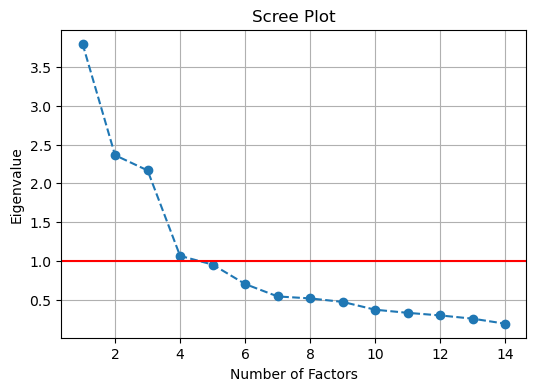


Optimal number of factors (Eigenvalue > 1): 4



Factor Loadings:
                                   Factor 1  Factor 2  Factor 3  Factor 4
Inflight wifi service             -0.118254 -0.740117 -0.106329 -0.258091
Departure/Arrival time convenient  0.008928 -0.518830 -0.051124  0.082549
Ease of Online booking             0.017820 -0.892371 -0.007709 -0.196152
Gate location                     -0.012638 -0.560164  0.032955  0.177689
Food and drink                    -0.779936 -0.040708  0.045720 -0.036453
Online boarding                   -0.250417 -0.269587 -0.047991 -0.857874
Seat comfort                      -0.741534  0.008281 -0.010308 -0.271377
Inflight entertainment            -0.804211 -0.052037 -0.417944 -0.058155
On-board service                  -0.132656 -0.020589 -0.690041 -0.096536
Leg room service                  -0.097972 -0.092149 -0.473165 -0.068422
Baggage handling                  -0.082763 -0.037304 -0.756995 -0.018552
Checkin service                   -0.100021  0.027725 -0.251406 -0.206449
Inflight service    

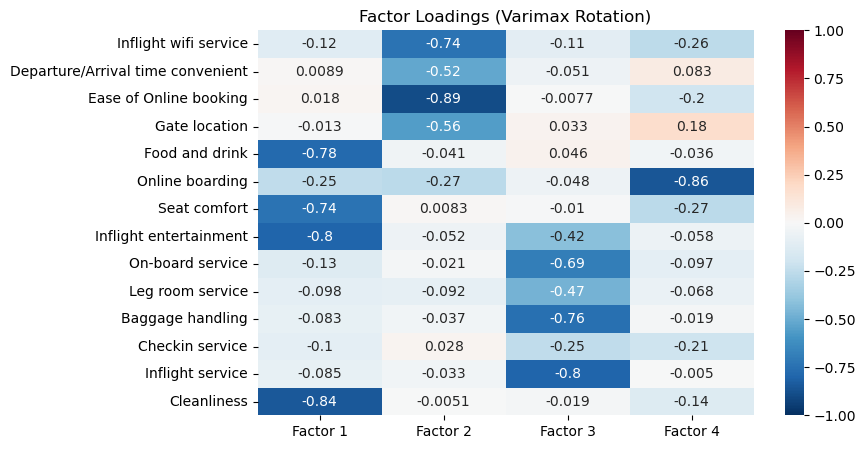

In [2]:
# 2. 탐색적 요인분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# 1. 데이터 전처리
# 서베이 항목 컬럼 선택
survey_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 
               'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 
               'Inflight entertainment', 'On-board service', 'Leg room service', 
               'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

X = df[survey_cols]

# 결측치 확인 및 처리 (0은 '평가 없음'일 수 있으나, 일단 척도로 간주하거나 분석에서 제외해야 함. 
# 여기서는 0도 하나의 응답으로 보고 진행하되, 만약 0이 결측이라면 mean imputation 등을 고려해야 함.
# 보통 0을 포함해서 분석하거나, 0을 NaN으로 보고 삭제함. 
# 이 데이터셋에서 0은 'Not Applicable'로 해석되기도 함. 
# 하지만 팩터 분석을 위해 그대로 진행하거나, 0을 제외한 평균으로 대체하는 것이 좋음.
# 여기서는 간단히 그대로 진행 (스케일링이 중요))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 적정 요인 수 결정 (Scree Plot & Eigenvalues)
# 상관계수 행렬의 고유값 계산
corr_matrix = np.corrcoef(X_scaled.T)
eigenvalues = np.linalg.eigvals(corr_matrix)
# 크기순 정렬
eigenvalues = np.sort(eigenvalues)[::-1]
print("Eigenvalues (top):", eigenvalues[:10])

# Scree Plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='-') # Kaiser's criterion
plt.grid()
plt.show()

# Kaiser 기준 (Eigenvalue > 1)에 따른 요인 수 결정
n_factors = sum(eigenvalues > 1)
print(f"\nOptimal number of factors (Eigenvalue > 1): {n_factors}")

# 3. 요인 분석 수행 (Factor Analysis)
# rotation='varimax'를 사용하여 해석력을 높임
fa = FactorAnalysis(n_components=n_factors, rotation='varimax', random_state=42)
fa.fit(X_scaled)

# 요인 적재량 (Factor Loadings) 확인
fa_components = pd.DataFrame(fa.components_.T, index=survey_cols, columns=[f'Factor {i+1}' for i in range(n_factors)])
print("\nFactor Loadings:")
print(fa_components)

# 시각화 (Heatmap)
plt.figure(figsize=(8, 5))
sns.heatmap(fa_components, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Factor Loadings (Varimax Rotation)')
plt.show()

In [3]:
import numpy as np
import pandas as pd

service_cols = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness",
]

X = df[service_cols].to_numpy(dtype=float)

# 표준화
Xz = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)

# 상관행렬
R = np.corrcoef(Xz, rowvar=False)

# 고유분해
eigvals, eigvecs = np.linalg.eigh(R)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

# 요인 수
k = 4

# 요인 적재량(주성분 요인추출)
L = eigvecs[:, :k] * np.sqrt(eigvals[:k])

def varimax(Phi, gamma=1.0, q=50, tol=1e-6):
    p, k = Phi.shape
    Rm = np.eye(k)
    d = 0.0
    for _ in range(q):
        d_old = d
        Lam = Phi @ Rm
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lam**3 - (gamma / p) * Lam @ np.diag(np.diag(Lam.T @ Lam)))
        )
        Rm = u @ vh
        d = s.sum()
        if d_old != 0 and d / d_old < 1 + tol:
            break
    return Phi @ Rm

L_rot = varimax(L)

# 요인별 SS(정렬)
ss = (L_rot**2).sum(axis=0)
order = np.argsort(ss)[::-1]
L_rot = L_rot[:, order]
ss = ss[order]

loading = pd.DataFrame(L_rot, index=service_cols, columns=[f"F{i+1}" for i in range(k)])

# 부호 정리(해석 편의)
for c in loading.columns:
    if loading[c].sum() < 0:
        loading[c] *= -1

print("Eigenvalues (top):", eigvals[:10])
print("\nSS loadings:", ss)
print("\nSS/14:", ss / len(service_cols), "sum:", (ss / len(service_cols)).sum())
print()
print(loading.round(3))

Eigenvalues (top): [3.80011677 2.36198598 2.16589224 1.06327401 0.95093123 0.7003355
 0.53995637 0.51465504 0.46947475 0.36866001]

SS loadings: [2.96894813 2.65727725 1.89930116 1.86574246]

SS/14: [0.21206772 0.18980552 0.13566437 0.13326732] sum: 0.6708049285312284

                                      F1     F2     F3     F4
Inflight wifi service              0.079  0.091  0.467  0.714
Departure/Arrival time convenient -0.010  0.085  0.751  0.130
Ease of Online booking            -0.052  0.002  0.594  0.675
Gate location                      0.013 -0.024  0.836  0.032
Food and drink                     0.853 -0.049  0.048  0.018
Online boarding                    0.298  0.032 -0.114  0.832
Seat comfort                       0.823  0.018 -0.071  0.206
Inflight entertainment             0.802  0.422  0.037  0.052
On-board service                   0.118  0.774 -0.020  0.084
Leg room service                   0.047  0.595 -0.043  0.195
Baggage handling                   0.070  0.824 